In [1]:
import os
import re
import math
import torch
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gidd.eval.generation_info import GenerationInfoHandler
from datasets import load_from_disk

mask_token_id = 9

/local/home/prisold/gidd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data

base_dir = "generation_info"
combination_row_ids = [1, 2]

dir_path_dict = {}
meta_dict = {}
history_dict = {}
logits_dict = {}
confidence_t_0_dict = {}
marginals_dict = {}
change_events_table_dict = {}
forward_calls_dict = {}
prune_correct_dict = {}
beam_search_forward_calls_dict = {}
beam_search_branch_correctness_dict = {}
beam_search_beam_correctness_dict = {}
denoise_config_dict = {}
combination_rows = []

for combination_row in combination_row_ids:
    dir_path = f"{base_dir}/combination_{combination_row}"
    meta, history, logits, confidence_t_0, marginals, change_events_table, forward_calls, prune_correct, beam_search_forward_calls, beam_search_branch_correctness, beam_search_beam_correctness = GenerationInfoHandler.load_all(dir_path)
    # meta, history, logits, confidence_t_0, marginals, change_events_table, forward_calls, prune_correct, beam_search_forward_calls, beam_search_branch_correctness = GenerationInfoHandler.load_all(dir_path)
    dir_path_dict[combination_row] = dir_path
    meta_dict[combination_row] = meta
    history_dict[combination_row] = history
    logits_dict[combination_row] = logits
    confidence_t_0_dict[combination_row] = confidence_t_0
    marginals_dict[combination_row] = marginals
    change_events_table_dict[combination_row] = change_events_table
    forward_calls_dict[combination_row] = forward_calls
    prune_correct_dict[combination_row] = prune_correct
    beam_search_forward_calls_dict[combination_row] = beam_search_forward_calls
    beam_search_branch_correctness_dict[combination_row] = beam_search_branch_correctness
    # beam_search_beam_correctness_dict[combination_row] = beam_search_beam_correctness
    denoise_config_dict[combination_row] = meta['sampling_strategy']['p_denoise']

    sampling_parameters = meta['sampling_strategy'].copy()
    if isinstance(sampling_parameters.get('p_denoise', None), dict):
        for k, v in sampling_parameters['p_denoise'].items():
            sampling_parameters[f'p_denoise_{k}'] = v
        del sampling_parameters['p_denoise']
    sampling_parameters['combination_row'] = combination_row
    combination_rows.append(sampling_parameters)

combinations_df = pd.DataFrame(combination_rows)

print(meta_dict[combination_row_ids[0]])

{'accuracy': 0.796875, 'correctly_filled_cells': 0.9154154062271118, 'nfe': 1.25, 'time_taken_s': 3.899017333984375, 'speed_samples_per_s': 16.414392273193336, 'created_at': '2025-12-01 16:23:56 GMT', 'num_samples': 64, 'max_seq_len': 81, 'collect_history': True, 'collect_logits': True, 'collect_confidence_t_0': False, 'collect_marginals': True, 'collect_change_events': True, 'collect_forward_calls': True, 'collect_prune_correct': False, 'collect_beam_search_forward_calls': False, 'collect_beam_search_branch_correctness': False, 'collect_beam_search_beam_correctness': False, 'general_sampling': {'device': 2, 'seed': 1, 'checkpoint': 'checkpoints/gidd_0_2/300_epochs', 'dataset': 'hard', 'num_samples': 64, 'num_denoising_steps': 80, 'num_self_correction_steps': 0, 'batch_size': 64, 'min_p': 0.0, 'compile_torch': 0, 'combinations_row': 1}, 'sampling_strategy': {'strategy': 'gidd_change_low_confidence_positions', 'time_steps': 'inferred', 'score_mask_position': 'MDM_max', 'score_position_f

In [3]:
print(marginals_dict[1].keys())
print(marginals_dict[1]['p_zt_x_mean'].shape)
print(marginals_dict[1]['p_zt_x_mean'][36])

dict_keys(['true_denoised_fraction', 'denoised_fraction', 'mask_fraction', 'uniform_fraction', 'p_zt_x_mean', 'p_zt_x_std', 'p_zt_x_min', 'p_zt_x_max', 'cell_accuracy', 'expected_cell_accuracy', 'total_accuracy'])
torch.Size([64, 81])
tensor([0.0000, 0.0179, 0.0357, 0.0535, 0.0714, 0.0892, 0.1069, 0.1247, 0.1426,
        0.1603, 0.1784, 0.1962, 0.2142, 0.2321, 0.2499, 0.2678, 0.2857, 0.3035,
        0.3214, 0.3392, 0.3571, 0.3749, 0.3928, 0.4106, 0.4285, 0.4463, 0.4642,
        0.4821, 0.4999, 0.5177, 0.5354, 0.5531, 0.5712, 0.5890, 0.6065, 0.6244,
        0.6423, 0.6580, 0.6772, 0.6936, 0.7112, 0.7285, 0.7463, 0.7655, 0.7832,
        0.7999, 0.8178, 0.8364, 0.8533, 0.8694, 0.8763, 0.8731, 0.8755, 0.8730,
        0.8752, 0.8731, 0.8744, 0.8734, 0.8744, 0.8734, 0.8744, 0.8735, 0.8767,
        0.8735, 0.8767, 0.8735, 0.8767, 0.8735, 0.8767, 0.8735, 0.8767, 0.8735,
        0.8767, 0.8735, 0.8767, 0.8735, 0.8767, 0.8735, 0.8767, 0.8735, 0.9599])


In [4]:
# print(logits_dict[1].shape)
# print(logits_dict[1][36, 60, 0, :])
# # print(logits_dict[1]['p_zt_x_mean'][36])

combination_row 1, {'strategy': 'gidd_change_low_confidence_positions', 'time_steps': 'inferred', 'score_mask_position': 'MDM_max', 'score_position_for_change': None, 'select_position': None, 'select_position_change': None, 'select_position_unmask': 'top_k_gumbel', 'change_token': 'change_max', 'unmask_token': 'MDM_max', 'k': 1, 'gumbel_noise_coefficient': 0.0, 'self_correction': 'none', 'p_denoise': {'oracle': 'model', 'position_sampling': 'independent', 'position_metric': 'p_denoise', 'token_sampling': 'categorical', 'uniform_noise': 'none'}}
combination_row 2, {'strategy': 'gidd_change_based_on_model_confidence_to_change', 'time_steps': 'inferred', 'score_mask_position': None, 'score_position_for_change': 'change_max', 'select_position': 'top_k_gumbel', 'select_position_change': None, 'select_position_unmask': None, 'change_token': 'change_max', 'unmask_token': None, 'k': 1, 'gumbel_noise_coefficient': 0.0, 'self_correction': 'none', 'p_denoise': {'oracle': 'model', 'position_sampli

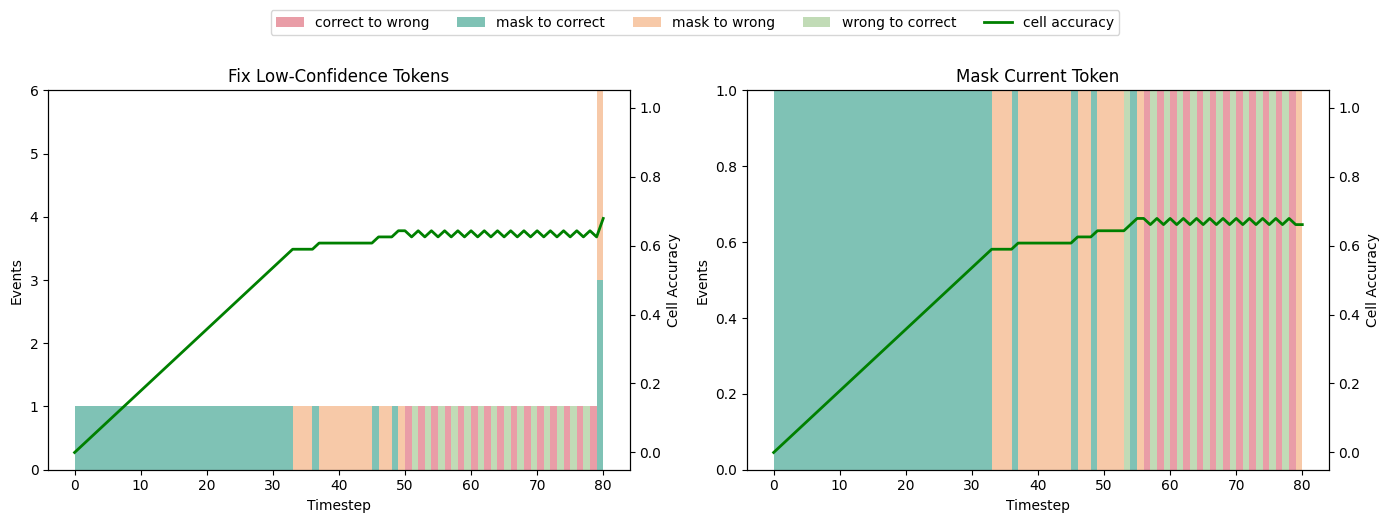

In [5]:
# Plot change events

# Define consistent color scheme for event types
event_colors = {
    'mask_to_denoised': '#00876c',
    'uniform_to_denoised': '#85b96f',
    'mask_to_uniform': '#f19452',
    'uniform_to_uniform': '#f7e382',
    'denoised_to_uniform': '#d43d51'
}
event_names = {
    'mask_to_denoised': 'mask to correct',
    'uniform_to_denoised': 'wrong to correct',
    'mask_to_uniform': 'mask to wrong',
    'uniform_to_uniform': 'wrong to wrong',
    'denoised_to_uniform': 'correct to wrong',
}
combination_row_to_name = {
    1: 'Fix Low-Confidence Tokens',
    2: 'Mask Current Token',
}

sample = 36
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Collect handles and labels for one global legend
all_handles, all_labels = [], []

num_timesteps = max([len(marginals_dict[c]['cell_accuracy']) for c in combination_row_ids])
timesteps = range(num_timesteps)

for ax, current_combination_row in zip(axs.flatten(), combination_row_ids):
    # Filter change events for the current sample
    change_events_table = change_events_table_dict[current_combination_row]
    # print(change_events_table.keys())
    # print(change_events_table[change_events_table['sample'] == sample].sort_values(by='step', ascending=False)[['step', 'event_type']].head(10))
    marginals = marginals_dict[current_combination_row]
    # print(type(marginals['cell_accuracy']))
    # print(marginals['cell_accuracy'].shape)
    # print(marginals['cell_accuracy'][0, 0])
    history = history_dict[current_combination_row]
    # print(history.shape)
    sample_events = change_events_table[change_events_table['sample'] == sample]
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()
    p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()

    # Plot number of events per step, colored by event_type
    event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)
    bottom = None
    for event_type in event_counts.columns:
        color = event_colors.get(event_type, None)
        bar = ax.bar(event_counts.index + 0.5, event_counts[event_type], bottom=bottom,
                     alpha=0.5, width=1, color=color, label=event_type)
        if bottom is None:
            bottom = event_counts[event_type]
        else:
            bottom += event_counts[event_type]

        # Collect legend entries only once
        if event_names.get(event_type, None) not in all_labels:
            all_handles.append(bar[0])
            all_labels.append(event_names.get(event_type, None))

    # Secondary y-axis
    ax2 = ax.twinx()

    # mean_conf_before = sample_events.groupby('step')['model_confidence'].mean()
    # line1, = ax2.plot(mean_conf_before.index, mean_conf_before.values,
    #                   color='black', linestyle='--', label='model_confidence_before')
    # mean_conf_after = sample_events.groupby('step')['model_confidence_after'].mean()
    # line2, = ax2.plot(mean_conf_after.index, mean_conf_after.values,
    #                   color='black', label='model_confidence_after')

    cell_accuracy = cell_accuracy[sample]
    timesteps = range(len(cell_accuracy))
    # p_zt_x_mean = p_zt_x_mean[sample]
    line3, = ax2.plot(timesteps, cell_accuracy, color='green', label='cell_accuracy', linewidth=2)
    # line4, = ax2.plot(timesteps, p_zt_x_mean, color='blue', label='p_zt_x_mean', linewidth=2)

    # Collect line labels only once
    for line, label in zip([line3],
                           ['cell accuracy']):
        if label not in all_labels:
            all_handles.append(line)
            all_labels.append(label)
    # for line, label in zip([line4],
    #                        ['mean current probability']):
    #     if label not in all_labels:
    #         all_handles.append(line)
    #         all_labels.append(label)

    print(f'combination_row {current_combination_row}, {meta_dict[current_combination_row]['sampling_strategy']}')
    ax.set_title(f'{combination_row_to_name[current_combination_row]}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Events')
    ax2.set_ylabel('Cell Accuracy')
    ax2.set_ylim(-0.05, 1.05)

# Shared legend for all subplots
# fig.legend(all_handles, all_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.legend(all_handles, all_labels, ncol=7, loc='upper center', bbox_to_anchor=(0.5, 1.05))

# plt.suptitle('fix before unmasking', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle + legend

plt.show()

# Use save button in notebook to avoid cutting off legend
# plt.savefig(base_dir + '/change_events.png') # cuts off legend

In [6]:
combination_row_to_name = {
    1: 'Fix Low-Confidence Tokens',
    2: 'Mask Current Token',
}

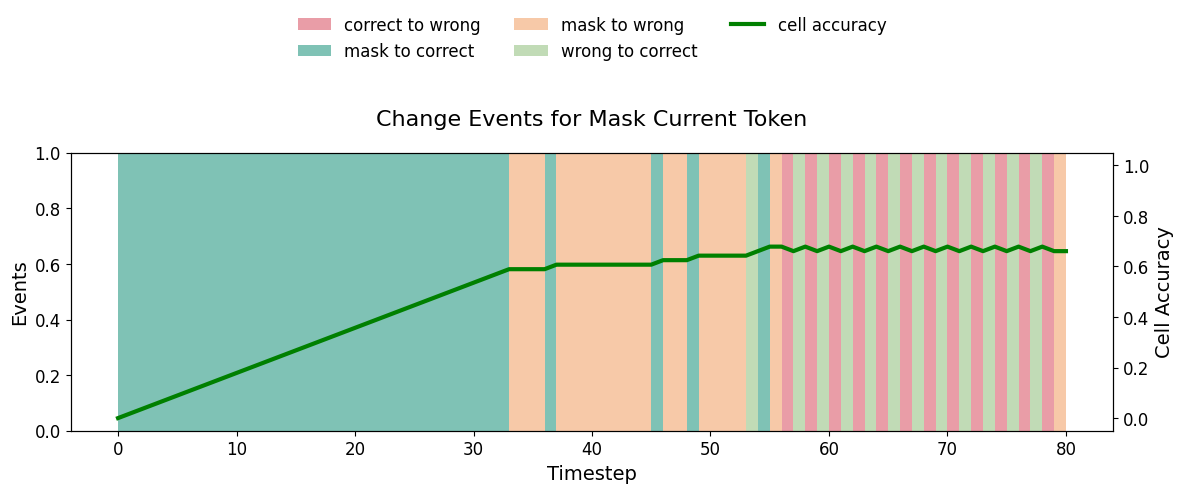

In [7]:
# Plot change events for Mask Current Token strategy only

# Define consistent color scheme for event types
event_colors = {
    'mask_to_denoised': '#00876c',
    'uniform_to_denoised': '#85b96f',
    'mask_to_uniform': '#f19452',
    'uniform_to_uniform': '#f7e382',
    'denoised_to_uniform': '#d43d51'
}
event_names = {
    'mask_to_denoised': 'mask to correct',
    'uniform_to_denoised': 'wrong to correct',
    'mask_to_uniform': 'mask to wrong',
    'uniform_to_uniform': 'wrong to wrong',
    'denoised_to_uniform': 'correct to wrong',
}

sample = 36
current_combination_row = 2  # Mask Current Token

# Reduce figure height and increase font sizes
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
plt.rcParams.update({'font.size': 12})

# Filter change events for the current sample
change_events_table = change_events_table_dict[current_combination_row]
marginals = marginals_dict[current_combination_row]
sample_events = change_events_table[change_events_table['sample'] == sample]
cell_accuracy = marginals['cell_accuracy'].cpu().numpy()

# Plot number of events per step, colored by event_type
event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)
bottom = None
handles = []
labels = []

for event_type in event_counts.columns:
    color = event_colors.get(event_type, None)
    bar = ax.bar(event_counts.index + 0.5, event_counts[event_type], bottom=bottom,
                 alpha=0.5, width=1, color=color, label=event_names.get(event_type, event_type))
    if bottom is None:
        bottom = event_counts[event_type]
    else:
        bottom += event_counts[event_type]
    
    handles.append(bar[0])
    labels.append(event_names.get(event_type, event_type))

# Secondary y-axis for cell accuracy
ax2 = ax.twinx()
cell_accuracy = cell_accuracy[sample]
timesteps = range(len(cell_accuracy))
line, = ax2.plot(timesteps, cell_accuracy, color='green', label='cell accuracy', linewidth=3)

# Add line to legend
handles.append(line)
labels.append('cell accuracy')

# Set title and labels with larger font sizes
ax.set_title(f'Change Events for {combination_row_to_name[current_combination_row]}', fontsize=16, pad=20)
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Events', fontsize=14)
ax2.set_ylabel('Cell Accuracy', fontsize=14)
ax2.set_ylim(-0.05, 1.05)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='y', which='major', labelsize=12)

# Legend with larger font and more space from plot
fig.legend(handles, labels, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.0), 
           fontsize=12, frameon=False)

# Leave more space for title and legend
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

# plt.savefig(base_dir + '/mask_current_token_change_events.png', bbox_inches='tight', dpi=300)

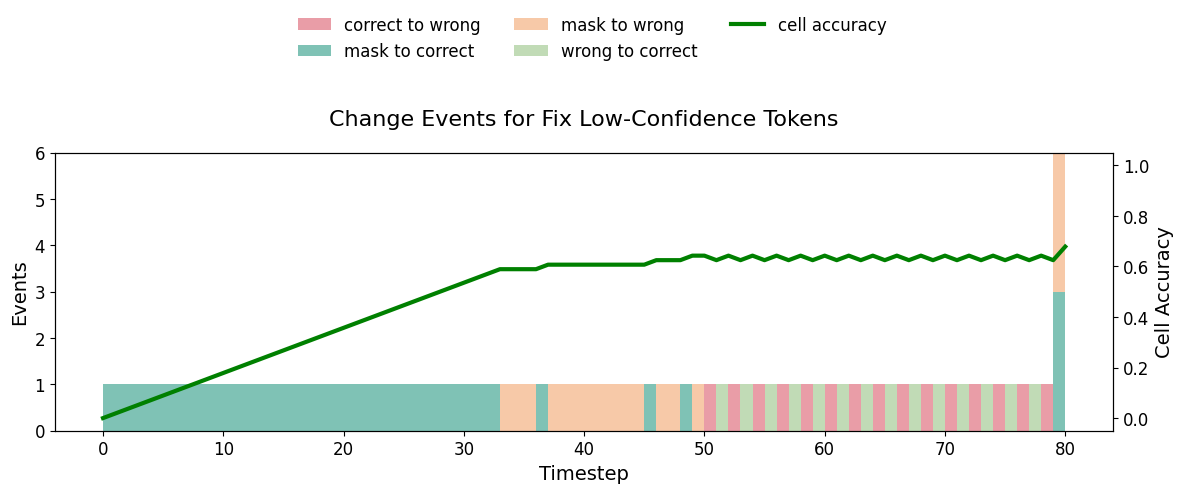

In [8]:
# Plot change events for Mask Current Token strategy only

# Define consistent color scheme for event types
event_colors = {
    'mask_to_denoised': '#00876c',
    'uniform_to_denoised': '#85b96f',
    'mask_to_uniform': '#f19452',
    'uniform_to_uniform': '#f7e382',
    'denoised_to_uniform': '#d43d51'
}
event_names = {
    'mask_to_denoised': 'mask to correct',
    'uniform_to_denoised': 'wrong to correct',
    'mask_to_uniform': 'mask to wrong',
    'uniform_to_uniform': 'wrong to wrong',
    'denoised_to_uniform': 'correct to wrong',
}

sample = 36
current_combination_row = 1  # Fix Low-Confidence Tokens

# Reduce figure height and increase font sizes
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
plt.rcParams.update({'font.size': 12})

# Filter change events for the current sample
change_events_table = change_events_table_dict[current_combination_row]
marginals = marginals_dict[current_combination_row]
sample_events = change_events_table[change_events_table['sample'] == sample]
cell_accuracy = marginals['cell_accuracy'].cpu().numpy()

# Plot number of events per step, colored by event_type
event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)
bottom = None
handles = []
labels = []

for event_type in event_counts.columns:
    color = event_colors.get(event_type, None)
    bar = ax.bar(event_counts.index + 0.5, event_counts[event_type], bottom=bottom,
                 alpha=0.5, width=1, color=color, label=event_names.get(event_type, event_type))
    if bottom is None:
        bottom = event_counts[event_type]
    else:
        bottom += event_counts[event_type]
    
    handles.append(bar[0])
    labels.append(event_names.get(event_type, event_type))

# Secondary y-axis for cell accuracy
ax2 = ax.twinx()
cell_accuracy = cell_accuracy[sample]
timesteps = range(len(cell_accuracy))
line, = ax2.plot(timesteps, cell_accuracy, color='green', label='cell accuracy', linewidth=3)

# Add line to legend
handles.append(line)
labels.append('cell accuracy')

# Set title and labels with larger font sizes
ax.set_title(f'Change Events for {combination_row_to_name[current_combination_row]}', fontsize=16, pad=20)
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Events', fontsize=14)
ax2.set_ylabel('Cell Accuracy', fontsize=14)
ax2.set_ylim(-0.05, 1.05)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='y', which='major', labelsize=12)

# Legend with larger font and more space from plot
fig.legend(handles, labels, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.0), 
           fontsize=12, frameon=False)

# Leave more space for title and legend
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

# plt.savefig(base_dir + '/mask_current_token_change_events.png', bbox_inches='tight', dpi=300)